In [1]:
import os

from keras.src.layers import layer

# Define dataset path
train_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/train/"

# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

I0000 00:00:1776245861.467392  199393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776245861.467746  199393 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776245861.504126  199393 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1776245863.061393  199393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776245863.061604  199393 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Check for corrupted images

In [2]:
from PIL import Image, UnidentifiedImageError
import os

corrupted_images = [] # List to store corrupted images path
 
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if  os.path.isdir(class_path): # is it valid dir ? 
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img)

if len(corrupted_images) > 0:
    print("\nCorrupted Images")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo Courrupted Images")


No Courrupted Images


### Count Class Balance

In [3]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


###  data augmentation layers

In [4]:
from tensorflow import keras

data_aug_layers = [
    keras.layers.RandomFlip("Horizontal"),
    keras.layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_aug_layers:
        images = layer(images)
    return images


E0000 00:00:1776245863.891832  199393 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776245863.892111  199626 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776245863.911050  199393 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Tasks

### Task 1: Use BN and Dropout on last workshop's exercise 

#### build data augmentation layers

In [5]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.1)
])

#### load the dataset

In [6]:
import tensorflow as tf

train_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/train/"
val_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/test/"

img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

train_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    interpolation = "nearest",
    batch_size = batch_size,
    shuffle =True,
    validation_split=validation_split,
    subset="training",
    seed=42
)

# creating validation dataset with normalization
val_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    interpolation = "nearest",
    batch_size = batch_size,
    shuffle = True,
    validation_split=validation_split,
    subset="validation",
    seed=42
)

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 90 files belonging to 6 classes.


Using 72 files for training.


Found 90 files belonging to 6 classes.


Using 18 files for validation.


#### building a model using BN and Dropout

In [7]:
from keras import Model, callbacks, layers

keras.backend.clear_session()  # resets all layer counters
input_shape = (128, 128, 3)

model = keras.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation, 

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, 1, padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, 1, padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, 1, padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(64, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    layers.Dense(6, activation="softmax"), # 6 classes
]) 

model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

print(model.summary())

# Data augmentation improves generalization by introducing variability in training samples.
# Batch Normalization stabilizes training and speeds convergence, 
# while Dropout reduces overfitting by randomly deactivating neurons.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,32

 Total params: 2,201,222 (8.40 MB)

 Trainable params: 2,200,390 (8.39 MB)

 Non-trainable params: 832 (3.25 KB)

None


## Task: Image Classification via fine tuning VGG16

### load the pretrained model

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input 

# pretrained on imagenet dataset, don't include final layers
base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)

# since we are not rescaling 
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

### freeze the layers

In [9]:
for layer in base_model.layers:
    layer.trainable = False

### add custom layers

In [10]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x) # reduce dimensions to single vector per image
x = layers.Dense(1024, activation='relu')(x) # fCNN layer
x = layers.Dropout(0.5)(x) # prevents overfitting
x = layers.Dense(6, activation='softmax')(x) # output layer with 6 class

### create final model

In [11]:
model = keras.Model(inputs=base_model.input, outputs=x)

### compile and fit the model

In [12]:
import json

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# make sure 
os.makedirs("./model_checkpoints", exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="./model_checkpoints/model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=0
)

print(history.history.keys())
print(json.dumps(history.history, indent=2))


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{
  "accuracy": [
    0.1666666716337204,
    0.4861111044883728,
    0.6666666865348816,
    0.6805555820465088,
    0.7916666865348816,
    0.7222222089767456,
    0.8472222089767456,
    0.9444444179534912
  ],
  "loss": [
    12.81353759765625,
    5.932448387145996,
    4.167420387268066,
    3.622129201889038,
    2.6506006717681885,
    3.659825325012207,
    1.1419481039047241,
    0.25227007269859314
  ],
  "val_accuracy": [
    0.2222222238779068,
    0.3888888955116272,
    0.3333333432674408,
    0.3333333432674408,
    0.3333333432674408,
    0.3888888955116272,
    0.4444444477558136,
    0.4444444477558136
  ],
  "val_loss": [
    7.807472229003906,
    8.424614906311035,
    6.268508434295654,
    5.507240295410156,
    7.793584823608398,
    7.3482513427734375,
    5.795035362243652,
    5.905272483825684
  ]
}


## fine tune: train the layers again

In [13]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    verbose=0
)

print(history.history.keys())
print(json.dumps(history.history, indent=2))

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{
  "accuracy": [
    0.7777777910232544,
    0.7777777910232544,
    0.8055555820465088,
    0.8472222089767456,
    0.8611111044883728,
    0.8333333134651184,
    0.9027777910232544,
    0.875,
    0.9444444179534912,
    0.9166666865348816,
    0.9444444179534912,
    0.9027777910232544,
    0.9444444179534912,
    0.9444444179534912,
    0.9583333134651184,
    0.9583333134651184,
    0.9722222089767456,
    0.9722222089767456,
    0.9583333134651184,
    0.9583333134651184
  ],
  "loss": [
    2.602532386779785,
    1.3456557989120483,
    0.9182862043380737,
    0.7809525728225708,
    0.5031226277351379,
    1.3473420143127441,
    0.466367244720459,
    0.7131384611129761,
    0.33056938648223877,
    0.3590463399887085,
    0.1774287074804306,
    0.3934594392776489,
    0.2547226846218109,
    0.09794312715530396,
    0.21619579195976257,
    0.2208973914384842,
    0.08682504296302795,
    0.08609005808830261,
    

## Task 2: transfer learning using a pretrained model

### load the pretrained model

In [14]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input 

# pretrained on imagenet dataset, don't include final layers
base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)

# since we are not rescaling 
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))


### freeze the layers

In [15]:
for layer in base_model.layers:
    layer.trainable = False

### add custom layers

In [16]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x) # reduce dimensions to single vector per image
x = layers.Dense(1024, activation='relu')(x) # fCNN layer
x = layers.Dropout(0.5)(x) # prevents overfitting
x = layers.Dense(6, activation='softmax')(x) # output layer with 6 class

### create final model

In [17]:
model = keras.Model(inputs=base_model.input, outputs=x)

### compile and fit the model

In [18]:
import json

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# make sure 
os.makedirs("./model_checkpoints", exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="./model_checkpoints/model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=0
)

print(history.history.keys())
print(json.dumps(history.history, indent=2))


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{
  "accuracy": [
    0.1111111119389534,
    0.4722222089767456,
    0.6111111044883728,
    0.6666666865348816,
    0.9027777910232544,
    0.8472222089767456,
    0.8888888955116272,
    0.9583333134651184,
    0.9861111044883728
  ],
  "loss": [
    14.917070388793945,
    7.584397315979004,
    3.4751691818237305,
    2.293999671936035,
    0.5893076062202454,
    0.8482705950737,
    0.8462696671485901,
    0.08569889515638351,
    0.09270704537630081
  ],
  "val_accuracy": [
    0.1666666716337204,
    0.4444444477558136,
    0.5,
    0.6111111044883728,
    0.5555555820465088,
    0.5555555820465088,
    0.6666666865348816,
    0.5555555820465088,
    0.5555555820465088
  ],
  "val_loss": [
    7.194525718688965,
    6.581143379211426,
    9.009239196777344,
    6.722296237945557,
    5.736599445343018,
    5.810342311859131,
    5.852743148803711,
    7.165261268615723,
    9.013944625854492
  ]
}


### Model Evaluation

In [19]:
test_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/test/"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    seed=42
)

class_names = test_ds.class_names 

loss, accuracy = model.evaluate(
    test_ds,
    verbose=0
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 30 files belonging to 6 classes.


Test Loss: 4.3809
Test Accuracy: 0.6667


### save and Load the Model

In [20]:
model.save('image_classifier_transfer_learning.h5')
loaded_model = tf.keras.models.load_model('image_classifier_transfer_learning.h5')

### Predictions and Classification Report

In [21]:
import numpy as np

# predict on test data
predictions = loaded_model.predict(test_ds, verbose=0)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
y_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {y_labels[0]}")

Predicted label for first image: 0
True label for first image: 0


### clasification report

In [22]:
from sklearn.metrics import classification_report

true_labels = []
predicted_labels = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# pass class names here ↓
report = classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0)
print(report)

              precision    recall  f1-score   support

        acai       0.56      1.00      0.71         5
     cupuacu       0.57      0.80      0.67         5
    graviola       1.00      0.60      0.75         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.67      0.40      0.50         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.67        30
   macro avg       0.72      0.67      0.66        30
weighted avg       0.72      0.67      0.66        30



### visualization

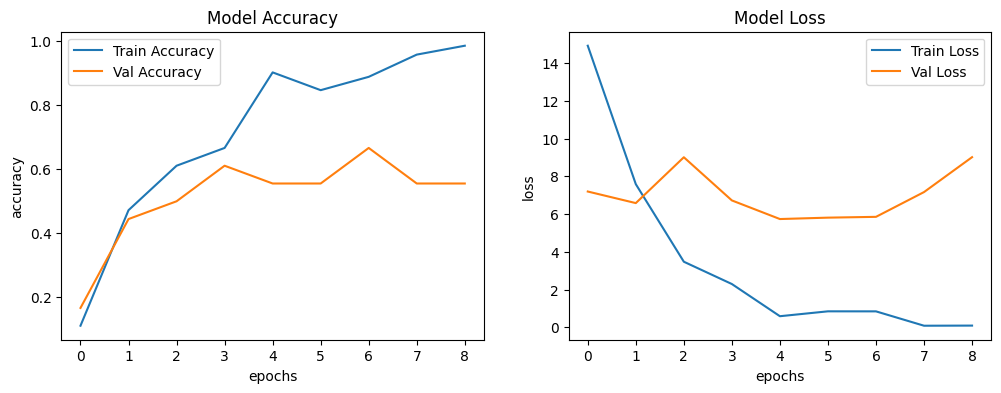

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

### performance improvement ?

- The pretrained convolutional layers act as a strong feature extractor,
  reducing the need for large training data and preventing overfitting compared to training a CNN from scratch.